# seq2seq 번역기

# 0. 라이브러리 import 및 setting

In [1]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
print(torch.__version__)

cuda
2.7.1+cu126


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

In [3]:
DATA_DIR = os.path.join(os.getcwd(), "data")
print(DATA_DIR)

KOR_FILE_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_FILE_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print(KOR_FILE_PATH)

/home/minkyujeong/work/DeepDive/ch5_seq2seq/data
/home/minkyujeong/work/DeepDive/ch5_seq2seq/data/korean-english-park.train.ko


In [4]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [5]:
plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {plt.rcParams['font.family']}")

설정된 폰트: ['NanumBarunGothic']


# 1. 데이터 준비

In [6]:
with open(KOR_FILE_PATH, "r") as f:
    raw_kor = f.read().splitlines()

print("Data Size:", len(raw_kor))
print("Example:")
for sen in raw_kor[0:100][::20]: print(">>", sen) # 5개 문장 출력

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


In [7]:
with open(ENG_FILE_PATH, "r") as f:
    raw_eng = f.read().splitlines()

print("Data Size:", len(raw_eng))
print("Example:")
for sen in raw_eng[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> Much of personal computing is about "can you top this?"
>> Amid mounting pressure on North Korea to abandon its nuclear weapons program Japanese and North Korean diplomats have resumed talks on normalizing diplomatic relations.
>> “Guard robots are used privately and professionally to detect intruders or fire,” Karlsson said.
>> Authorities from the Water Resources Ministry plan to begin construction next year on the controversial and hugely expensive project.
>> Researchers also have debated whether weight-training has a big impact on the heart, since it does not give the heart and lungs the kind of workout they get from aerobic activities such as brisk walking or running for at least 20 minutes.


In [8]:
raw_df = pd.DataFrame({'kor': raw_kor, "eng": raw_eng})
raw_df.head()

,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## 1.1 데이터 전처리

### 1.1.1 중복 제거

- 한국어, 영어 둘다 중복인 것은 제거 필요 (동일한 데이턱가 몇 번씩 들어가면 bias가 생길 수 있으므로)

In [9]:
print("한국어, 영어 둘다 중복인 데이터: ", raw_df.duplicated(subset=['kor', 'eng'], keep=False).sum())

한국어, 영어 둘다 중복인 데이터:  21910


In [10]:
raw_df[raw_df.duplicated(subset=['kor', 'eng'], keep=False)][:4]

,kor,eng
7750,이들 의원 중 1명은 빌 클린턴 전 대통령이 지난 몇 주간 부인 힐러리에게 오바마의...,"One of the lawmakers said Clinton's husband, f..."
7789,이들 의원 중 1명은 빌 클린턴 전 대통령이 지난 몇 주간 부인 힐러리에게 오바마의...,"One of the lawmakers said Clinton's husband, f..."
9918,*판매 제품,The goods
9925,*판매 제품,The goods


In [11]:
raw_df.drop_duplicates(subset=['kor', 'eng'], inplace=True)
print('전체 샘플수 :', (len(raw_df)))

전체 샘플수 : 78968


- 영어만 중복인 데이터  
&rarr; 영어 표현을 생성할 때 다양한 한국어 문장의 의미를 담을 수 있으므로, 각 케이스의 중복 건수와 문장을 보고 결정

In [12]:
raw_df[raw_df.duplicated(subset=['eng'], keep=False)][:4]

,kor,eng
6848,해리 왕자는 찰스 왕세자와 1997년 파리에서 교통사고로 사망한 다이애나 왕비와의 ...,Prince Harry is the younger son of Prince Char...
7111,"신화통신은 관계 당국의 말을 인용, 폭우가 10일 더 계속되어 강의 수위가 높아질 ...",Authorities said that torrential rains are exp...
7112,"이번 폭우로 지난달 2일 리히터 규모 7.9의 강진이 발생한 쓰촨성을 포함, 9개 ...",The flood has hit nine provinces the hardest &...
7218,"신화통신은 중국 당국의 말을 인용, 이번 폭우가 앞으로 10일간 더 쏟아져 언색호 ...",Authorities said that torrential rains are exp...


In [13]:
print("영어만 중복인 데이터: ", raw_df.duplicated(subset=['eng'], keep=False).sum())

영어만 중복인 데이터:  6687


In [14]:
# eng 컬럼의 빈도수를 계산하여 데이터프레임으로 변환
eng_counts = raw_df['eng'].value_counts().reset_index()
eng_counts.columns = ['eng', 'count']

# 그 중 중복된 것(2번 이상 등장)만 필터링
duplicate_counts = eng_counts[eng_counts['count'] > 1]

print(duplicate_counts)

                                                    eng  count
0                                ÏÀ» Á¦°øÇÏÁö ¾Ê½À´Ï´Ù.     18
1                   This material may not be published.     13
2     Copyright 2006 The Associated Press All rights...     10
3                                  ÇÑ±Û´º½ºÀÇ ¿ø¹ ®Àºµû      6
4                                  All rights reserved.      6
...                                                 ...    ...
3312  Amid soaring crude oil prices, the refineries ...      2
3313  The police chief has refused to resign after t...      2
3314  Hawking had canceled an appearance at Arizona ...      2
3315  In a keynote speech, Unification Minister Lee ...      2
3316  Search and rescue teams combed the jungles of ...      2

[3317 rows x 2 columns]


In [15]:
raw_df.drop_duplicates(subset=['eng'], inplace=True)
print('전체 샘플수 :', (len(raw_df)))

전체 샘플수 : 75598


- 한국어만 중복인 데이터  
&rarr; 같은 한국어 문장이라도 다양한 영어 문장으로 표현할 수 있으므로, 각 케이스의 중복 건수와 문장을 보고 결정

In [16]:
print("한국어만 중복인 데이터: ", raw_df.duplicated(subset=['kor'], keep=False).sum())

한국어만 중복인 데이터:  1058


In [17]:
raw_df[raw_df.duplicated(subset=['kor'], keep=False)]

,kor,eng
27,어휘 :,"The Geneva-based commission, in its annual stu..."
30,어휘 :,Postal Service - whose postmaster told a Senat...
282,어휘 :,the United States will take every measure agai...
1456,어휘 :,aid groups set up freshwater tanks to provide ...
2226,어휘 :,communications with the tiny $4.5 million DASH...
...,...,...
93720,원문 & 독해설명 인쇄,The incident occurred in MBC's live television...
93724,일어사전,Sovereign sold its 7 percent stake in LG Corp.
93779,국어사전,"The Korea Herald reports Wal-Mart Korea, the l..."
93891,원문 & 독해설명 인쇄,The per-pack cigarette tax goes from 39 cents ...


In [18]:
raw_df.drop_duplicates(subset=['kor'], inplace=True)
print('전체 샘플수 :', (len(raw_df)))

전체 샘플수 : 74786


#### 결측치 확인

In [19]:
print(raw_df.isnull().sum())

kor    0
eng    0
dtype: int64


### 1.1.2. 데이터 정제

In [20]:
# 한국어 정제 함수
def preprocess_kor_sentence(sentence):   
    
    # 1. 양끝 공백 제거
    sentence = sentence.strip()
    
    # 2. 연속된 공백을 하나로 통일 (스페이스, 탭 등)
    sentence = re.sub(r'\s+', ' ', sentence)
    
    # 3. 연속된 개행문자(\n) 정제
    # 문장 구분을 위해 \n은 살려두되, 2개 이상 연속되면 1개로 줄임
    sentence = re.sub(r'\n+', '\n', sentence)
    
    # 4. 반복되는 자음/모음 정제 (예: ㅋㅋㅋㅋ -> ㅋㅋ)    
    sentence = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', sentence)
    
    # 5. 반복되는 특수문자 정제 (예: .... -> ..)
    sentence = re.sub(r'([\.\!\?])\1+', r'\1\1', sentence)

    return sentence

In [21]:
# # 영어 정제 함수
# def preprocess_eng_sentence(sentence):
#     sentence = sentence.lower().strip() # 소문자로 만들고 양쪽 공백 제거
#     sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
#     sentence = re.sub(r'[" "]+', " ", sentence)
#     sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence) # +: &&& -> " " / + 없으면: &&& -> " "" "" "

#     sentence = sentence.strip()

#     return sentence

In [22]:
from nltk.corpus import stopwords

In [23]:
stop_words = set(stopwords.words('english'))
# 영어 정제 함수 (불용어 제거 추가)
def preprocess_eng_sentence(sentence, remove_stopwords=False):
    sentence = sentence.lower().strip() # 소문자로 만들고 양쪽 공백 제거
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence) # +: &&& -> " " / + 없으면: &&& -> " "" "" "

    sentence = sentence.strip()
    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words and len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [24]:
raw_df['kor'] = raw_df['kor'].apply(preprocess_kor_sentence)
raw_df['eng'] = raw_df['eng'].apply(preprocess_eng_sentence, remove_stopwords=True)

In [25]:
# eng sentence 단어 개수 확인
eng_count = []
for eng_sent in raw_df['eng']:
    eng_count.append(len(eng_sent.split()))

eng_count = np.array(eng_count)
print(np.max(eng_count))
print(np.mean(eng_count))
print(np.median(eng_count))

63
13.215334420880913
13.0


&rarr; 평균적으로 24개의 단어를 갖고 있어서 v0.9 파일에서는 불용어 제거는 하지 않았으나(Ex_05_seq2seq_v0.9.ipynb 참조),  
&rarr; 번역 결과 의미없지만 자주 등장하는 단어들이 나와서 본 파일에서는 불용어를 제거하였음

#### 중복 여부 재확인

In [26]:
print("한국어, 영어 둘다 중복인 데이터: ", raw_df.duplicated(subset=['kor', 'eng'], keep=False).sum())
print("영어만 중복인 데이터: ", raw_df.duplicated(subset=['eng'], keep=False).sum())
print("한국어만 중복인 데이터: ", raw_df.duplicated(subset=['kor'], keep=False).sum())

한국어, 영어 둘다 중복인 데이터:  0
영어만 중복인 데이터:  291
한국어만 중복인 데이터:  6


In [27]:
raw_df.drop_duplicates(subset=['eng'], inplace=True)
print('전체 샘플수 :', (len(raw_df)))

전체 샘플수 : 74573


In [28]:
raw_df.drop_duplicates(subset=['kor'], inplace=True)
print('전체 샘플수 :', (len(raw_df)))

전체 샘플수 : 74570


#### 결측치 확인

In [29]:
print(raw_df.isnull().sum())

kor    0
eng    0
dtype: int64


#### 파일로 저장

In [30]:
kor_path = os.path.join(DATA_DIR, "kor_corpus_train.txt")
eng_path = os.path.join(DATA_DIR, "eng_corpus_train.txt")
raw_df["kor"].to_csv(kor_path, index=False, header=False, sep="\n", encoding="utf-8")
raw_df["eng"].to_csv(eng_path, index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: kor_corpus_train.txt, eng_corpus_train.txt")

파일 저장 완료: kor_corpus_train.txt, eng_corpus_train.txt


### 1.2. 토크나이징

In [31]:
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

enc_path = os.path.join(DATA_DIR, "encoder_kor_train_spm")
dec_path = os.path.join(DATA_DIR, "decoder_eng_train_spm")

In [32]:
# 한국어 인코더 토크나이징
VOCAB_SIZE_KOR = 10000

spm.SentencePieceTrainer.train(
    input = kor_path,
    model_prefix = enc_path,
    vocab_size = VOCAB_SIZE_KOR,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/kor_corpus_train.txt
  input_format: 
  model_prefix: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/encoder_kor_train_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>

In [33]:
# 영어 디코더 토크나이징
VOCAB_SIZE_ENG = 10000

spm.SentencePieceTrainer.train(
    input = eng_path,
    model_prefix = dec_path,
    vocab_size = VOCAB_SIZE_ENG,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/eng_corpus_train.txt
  input_format: 
  model_prefix: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/decoder_eng_train_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>

In [34]:
enc_tokenizer = spm.SentencePieceProcessor()
enc_tokenizer.load(os.path.join(DATA_DIR, "encoder_kor_train_spm.model"))

dec_tokenizer = spm.SentencePieceProcessor()
dec_tokenizer.load(os.path.join(DATA_DIR, "decoder_eng_train_spm.model"))

True

In [35]:
kor_sample = raw_df['kor'][100]
eng_sample = raw_df['eng'][100]
print(kor_sample)
print(eng_sample)

제 23차 연례 컴덱스 박람회의 개회사를 한 케이츠는 2년여전 기술 산업의 거품이 붕괴된 이후에 첨단 기술에 대해 부정적인 인식이 있다고 말했다.
gates opened rd annual comdex trade show said negative perception high tech following collapse tech bubble two years ago


In [36]:
enc_tok = enc_tokenizer.encode(kor_sample)
enc_tok = [enc_tokenizer.bos_id()] + enc_tok + [enc_tokenizer.eos_id()]
enc_tok

[1,
 189,
 734,
 230,
 6732,
 5,
 4385,
 9345,
 50,
 1337,
 2483,
 1269,
 539,
 1490,
 8,
 59,
 4170,
 4125,
 46,
 36,
 231,
 135,
 603,
 1305,
 7,
 267,
 676,
 11,
 8104,
 134,
 9,
 8514,
 603,
 9,
 68,
 4927,
 21,
 2991,
 11,
 84,
 35,
 4,
 2]

In [37]:
enc_decode = enc_tokenizer.decode(enc_tok)
enc_decode

'제 23차 연례 컴덱스 박람회의 개회사를 한 케이츠는 2년여전 기술 산업의 거품이 붕괴된 이후에 첨단 기술에 대해 부정적인 인식이 있다고 말했다.'

##  1.3. 학습 데이터로 변환

### 1.3.1. MAX_TOKEN_LEN 결정

In [38]:
enc_tokenizer = spm.SentencePieceProcessor()
enc_tokenizer.load(os.path.join(DATA_DIR, "encoder_kor_train_spm.model"))

dec_tokenizer = spm.SentencePieceProcessor()
dec_tokenizer.load(os.path.join(DATA_DIR, "decoder_eng_train_spm.model"))

True

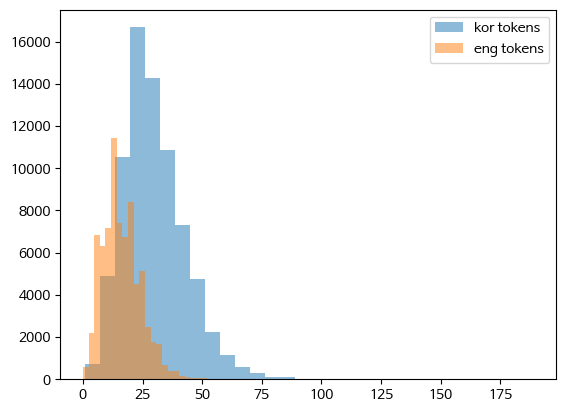

kor 토큰 최대: 189
eng 토큰 최대: 71


In [39]:
kor_token_lens = [len(enc_tokenizer.encode_as_ids(kor_sentence)) for kor_sentence in raw_df['kor']]
eng_token_lens = [len(dec_tokenizer.encode_as_ids(eng_sentence)) for eng_sentence in raw_df['eng']]

plt.hist(kor_token_lens, bins=30, alpha=0.5, label='kor tokens')
plt.hist(eng_token_lens, bins=30, alpha=0.5, label='eng tokens')
plt.legend()
plt.show()

print(f"kor 토큰 최대: {max(kor_token_lens)}")
print(f"eng 토큰 최대: {max(eng_token_lens)}")

In [41]:
# BOS, EOS 토큰 고려하면 최소 80이상 지정 필요
# inference 단계에서 더 긴 글이 들어올 수 있으므로 128로 지정하고
# 편의상 인코더, 디코더 공용으로 사용
MAX_TOKEN_LEN = 256

### 1.3.2. Dataset 및 DataLoader 생성

In [42]:
class TransDataset(Dataset):

    def __init__(self, data, enc_tokenizer, dec_tokenizer, max_len):
        self.data = data
        self.enc_tokenizer = enc_tokenizer
        self.dec_tokenizer = dec_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2        
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        tgt_text = self.data.iloc[idx]['eng']

        src_ids = self.enc_tokenizer.encode(src_text)
        tgt_ids = self.dec_tokenizer.encode(tgt_text)

        src_ids = src_ids[:self.max_len]

        # decoder의 입력에 bos, eos 토큰 추가, 단, 최대 길이 제한을 적용
        # tgt_input = [self.bos_id] + tgt_ids[:self.max_len-2] + [self.eos_id] 
        tgt_input = [self.bos_id] + tgt_ids[:self.max_len-1]
        tgt_label = tgt_ids[:self.max_len-1] + [self.eos_id]


        # 길이가 짧은 경우 PAD 토큰 추가
        src_ids = src_ids + [self.pad_id]*(self.max_len - len(src_ids))
        tgt_input = tgt_input + [self.pad_id]*(self.max_len - len(tgt_input))
        tgt_label = tgt_label + [self.pad_id]*(self.max_len - len(tgt_label))

        return torch.tensor(src_ids), torch.tensor(tgt_input), torch.tensor(tgt_label)

In [43]:
BATCH_SIZE = 32

train_dataset = TransDataset(raw_df, enc_tokenizer, dec_tokenizer, MAX_TOKEN_LEN)
train_loader = DataLoader(dataset = train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [44]:
len(train_loader)

2331

In [45]:
for src, tgt_input, tgt_label in train_loader:
    print(src.shape, tgt_input.shape, tgt_label.shape)
    break

torch.Size([32, 256]) torch.Size([32, 256]) torch.Size([32, 256])


# 2. 모델 정의

In [46]:
# Bahdanau Attention 사용
class BahdanauAttn(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.w_enc = nn.Linear(hidden_dim, hidden_dim)
        self.w_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, single_hidden, enc_out):
        # single_hidden: (batch, h_dim) # 한 시점(토큰)의 hidden_state
        # enc_out: (batch, seq_len, h_dim) # batch_first로 받아온 enc_out (encoder의 모든 시점 hidden_state)

        src_seq_len = enc_out.shape[1]
        
        # (batch, h_dim) -> (batch, src_seq_len, h_dim) 
        # (1, src_seq_len, 1)에서 1: batch, 1: h_dim 그대로 유지됨
        single_hidden = single_hidden.unsqueeze(1).repeat(1, src_seq_len, 1)                 

        energy = torch.tanh(self.w_enc(enc_out) + self.w_dec(single_hidden)) # (batch, src_seq_len, hidden_dim)
        # (batch, src_seq_len, hidden_dim) -> (batch, src_seq_len, 1) -> (batch, src_seq_len)
        attn_weights = self.v(energy).squeeze(2) 

        return F.softmax(attn_weights, dim=1) # src_seq_len (전체 time, 토큰)에 대한 softmax 


In [47]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, h_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.h_dim = h_dim

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, h_dim, batch_first=True)

    def forward(self, src):
        # x: (batch, seq_len)
        emb_vec = self.embedding(src) # (batch, seq_len, emb_dim)
        # print("emb_shape:     ", emb_vec.shape)
        out, h = self.rnn(emb_vec) 
        # out : (batch, seq_len, h_dim*direction)  # batch_first 
        # h, c: seq_len 마지막 요소(layer*direction, batch, h_dim)
        return out, h

In [48]:
enc = Encoder(10000, 256, 512)
out, h = enc(torch.randint(0, 10000, (10, 30)))
print(out.shape, h.shape)
print((out[0, -1] == h[0, 0]).all())

torch.Size([10, 30, 512]) torch.Size([1, 10, 512])
tensor(True)


In [49]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, h_dim, attn):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.h_dim = h_dim

        self.attn = attn # (batch, src_seq_len) 가져옴
        self.embedding = nn.Embedding(vocab_size, emb_dim) # (batch, seq_len) -> (batch, seq_len, imb_dim)
        self.rnn = nn.GRU(emb_dim, h_dim, batch_first=True)
        # 출력층에는 hidden과 attn values가 결합되어 입력
        self.fc_out = nn.Linear(h_dim + h_dim, vocab_size) # attn(enc_out, dec_h_t-1), dec_h_t을 concat
    
    
    def forward(self, tgt_input, hidden, enc_out):
        # 하나의 토큰(time) 단위 계산하는 구조를 상정하고 짠 코드임 -> look-ahead mask 처리 안 해도 됨
        # tgt_input: (batch, ) -> [64] # (batch, 1) 아님 주의 # 해당 시점의 토큰을 batch 개수 만큼 처리 
        # hidden: (batch, h_dim) (n_layer*direction, batch, h_dim) # 마지막 시점(토큰)의 hidden state
        # hidden[-1]: (batch, h_dim) # 마지막 layer(time, 토큰 아님)의 hidden_state
        # enc_out (batch_first): (batch, seq_len, h_dim) # 이름은 out이지만 모든 time(토큰)의 hidden_state임
        
        tgt_input = tgt_input.unsqueeze(1) # (batch,) -> (batch, 1)        
        # tgt input 임베딩화
        emb = self.embedding(tgt_input) # (batch, 1, emb_dim)
        # print(emb.shape)
        # print("hidden   ", hidden.shape)
        # print("enc_out  ", enc_out.shape)

        # attn value 계산 (enc_out, 이전 스텝 hidden 이용)        
        # decoder의 이전 hidden state인 s_{t-1}, enc_out인 H가 입력
        # (batch, h_dim), (batch, src_len, h_dim) 넣고 연산해서 (batch, src_seq_len) 가져옴
        attn_weights = self.attn(hidden[-1], enc_out) # (batch, src_seq_len)        

        # H(enc_out, 인코더 전체 hidden_state)에 가중치를 부여해 attn values (context vector)계산
        attn_weights = attn_weights.unsqueeze(1) # (batch, src_seq_len) -> (batch, 1, src_seq_len)
        # (batch, 1, src_len), (batch, src_len, h_dim) 
        # -> (batch, 1, h_dim) 현재 시점(t)의 디코더 hidden_state에 더해줄 수 있게 됨
        attn_values = torch.bmm(attn_weights, enc_out) # (batch, 1, h_dim)
        attn_values = attn_values.permute(1, 0, 2) # (1, batch, h_dim) 왜냐하면 rnn의 h가 (1, batch, h_dim)으로 나오니까
        
        # 이전 시점(t-1)의 hidden을 같이 넣어줌 (한 시점,토큰씩 계산하니까)
        # print("dec input emb.....", emb.shape)
        # print("hidden emb.....", hidden.shape)
        out, cur_h = self.rnn(emb, hidden) # (batch, 1, emb_dim), (n_layer*direction, batch, h_dim) 
        # out: (batch, 1, h_dim) # batch_first 써서
        # cur_h: 현재 시점 hidden_state (n_layer*direction, batch, h_dim)        

        # 한 시점(토큰) 단위로 돌리니까 현재 out이랑 현재 hidden은 동일하게 나와야 함
        # print("한 시점 비교:", out.squeeze(1) == cur_h[-1]) # [True, True, ...]

        # 출력층에서는 현재 hidden_state와 attn_values(context vector)를 결합하여 예측값 생성
        out = out.squeeze(1) # (batch, 1, h_dim) -> (batch, h_dim)
        attn_values = attn_values.squeeze(0) # (batch, h_dim)
        pred = self.fc_out(torch.cat([out, attn_values], dim=1)) # (batch, vocab_size)

        # (batch, vocab_size), (n_layer*direction, batch, h_dim), (batch, src_seq_len)
        return pred, cur_h, attn_weights.squeeze(1)

- 특징  
디코더에서 병렬 처리(트랜스포머처럼 모든 시점을 한 번에 입력 안 함)가 아니라 한 시점(토큰)씩 처리 &rarr; Look-ahead mask 필요 없음

In [50]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt=None, max_len=30, bos_id=1, eos_id=2):
        # 학습 모드에서는 tgt_seq_len 사용, 추론 모드에서는 max_len까지 동적 생성
        # batch_size = src.shape[1] 
        
        batch_size = src.shape[0]
        # tgt_vocab_size = self.decoder.vocab_size
        tgt_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 list 사용 (길이가 조절이 tesnor보다 유연하다는 의미)
        outputs = []
        # 시각화를 위해 attention 저장
        attns = []
        # 인코더를 통해 context 생성
        enc_outs, enc_h = self.encoder(src) # (batch, src_len, h_dim), (n_layers*direction, batch, h_dim)
        

        dec_h = enc_h # 헷갈려서 변수 구분, 디코더 맨 첫 셀의 h는 enc_h이 들어가야 해서 넘겨줌
        if tgt is not None:                      
            for t in range(tgt.shape[1]): # dec_seq_len 만큼 반복해야 함. 한 토큰(시점) 단위로 돌리니까
                # bos부터 집어 넣음
                dec_input = tgt[:, t] # (batch,) [64] -> unsqueeze(1) 필요, decoder에서 수행
                # print("input_shape   ", dec_input.shape)
                dec_out, dec_h, attn = self.decoder(dec_input, dec_h, enc_outs) # 첫번째 입력 dec_h는 enc_h
                outputs.append(dec_out.unsqueeze(1)) # (batch, vocab_size) -> # (batch, 1, vocab_size)
                attns.append(attn.unsqueeze(1)) # (batch, src_seq_len) -> (batch, 1, src_seq_len)                

        else:
            # inference에서는 tgt_label이 없기 때문에 sos_token을 생성
            dec_input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device) # [bos_id, bos_id, ... ]
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device) # [False, False, ... ]

            for t in range(max_len):
                dec_out, dec_h, attn = self.decoder(dec_input, dec_h, enc_outs) # 첫번째 입력 dec_h는 enc_h
                outputs.append(dec_out.unsqueeze(1)) # batch_first로 얻어서
                attns.append(attn.unsqueeze(0))
                top1 = dec_out.argmax(dim=1) # (batch, vocab_size) -> vocab 중 가장 높은 확률의 단어 선택
                dec_input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id) # 한 번이라도 True 나오면 finished 요소 전부 True로 할당
                if finished.all():
                    break
        
        # outputs = torch.cat(outputs, dim=0) # batch, tgt_len, out_dim
        # attns = torch.cat(attns, dim=0) # batch, tgt_len, out_dim
        
        outputs = torch.cat(outputs, dim=1) # (batch, 1, vocab_size) -> (batch, tgt_len, vocab_size)
        attns = torch.cat(attns, dim=1) # (batch, 1, src_seq_len) -> (batch, tgt_len, src_seq_len)        

        return outputs, attns

# 3. 모델 학습

In [51]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

enc_vocab_size = len(enc_tokenizer) # vocab_size
print(enc_vocab_size)
dec_vocab_size = len(dec_tokenizer)
print(dec_vocab_size)

emb_dim = 256
# h_dim = 512
h_dim = 256

10000
10000


In [52]:
encoder = Encoder(enc_vocab_size, emb_dim, h_dim).to(DEVICE)
attention = BahdanauAttn(h_dim).to(DEVICE)
decoder = Decoder(dec_vocab_size, emb_dim, h_dim, attention).to(DEVICE)
model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

In [53]:
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [54]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    # desc: 진행바 맨 앞에 붙을 제목
    # leave=True: 100% 되었을 때(1 에폭 완료 시) 결과 그대로 남김 (이전 에폭 결과 볼 수 있음)
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, tgt_input, tgt_label in progress_bar:
        # 모델의 입력 순서에 맞게 변환        
        # src = src.permute(1, 0).to(device)
        # trg_input = trg_input.permute(1, 0).to(device)
        # trg_label = trg_label.permute(1, 0).to(device)
        
        # (batch, seq_len) 으로 넣음 (batch_first 써서)
        src = src.to(DEVICE) 
        tgt_input = tgt_input.to(DEVICE)
        tgt_label = tgt_label.to(DEVICE)

        optimizer.zero_grad()

        outputs, _ = model(src, tgt_input)

        # (batch, tgt_seq_len, h_dim) -> (batch*tgt_len, h_dim)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        # print(tgt_label.shape)
        tgt_label = tgt_label.reshape(-1) # 1차원 정수 라벨 (batch*tgt_seq_len, ) 
        # print(tgt_label.shape)

        loss = criterion(outputs, tgt_label) # 한 시점(토큰)에 대해 batch 단위 loss 계산
        loss.backward()
        
        # gradient vector의 norm(크기)를 1로 제한해서 기울기 폭주 방지
        # 기울기 norm = 4 -> 전체 요소 x 0.25
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        # 진행 바의 맨 뒤(오른쪽)에 표시될 텍스트를 설정 
        # set_postfic('화면에 표시될 이름(문자열로 출력됨)' = 변수(출력할 값))
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader) # 배치 단위 loss 다 더했으니까 전체 배치 개수로 나눠줌

In [55]:
EPOCHS = 10
history = {'train_loss':[]}

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    # val_loss = val_step(model, train_loader, optimizer, criterion, epoch)
    history['train_loss'].append(train_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 2331/2331 [15:43<00:00,  2.47it/s, loss=5.8] 


Epoch 1/10, Train Loss: 6.7305


Epoch 2: 100%|██████████| 2331/2331 [15:51<00:00,  2.45it/s, loss=4.92]


Epoch 2/10, Train Loss: 5.3893


Epoch 3: 100%|██████████| 2331/2331 [15:30<00:00,  2.51it/s, loss=4.5] 


...

Epoch 8/10, Train Loss: 3.0108


Epoch 9: 100%|██████████| 2331/2331 [14:31<00:00,  2.67it/s, loss=3.21]


Epoch 9/10, Train Loss: 2.8299


Epoch 10: 100%|██████████| 2331/2331 [15:01<00:00,  2.59it/s, loss=2.8] 

Epoch 10/10, Train Loss: 2.6735


#### Learning curve

In [56]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(6, 4))

    # 1. Loss 그래프 (왼쪽)
    # plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    # plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training Loss')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # 그래프 간 간격 자동 조절
    plt.show()

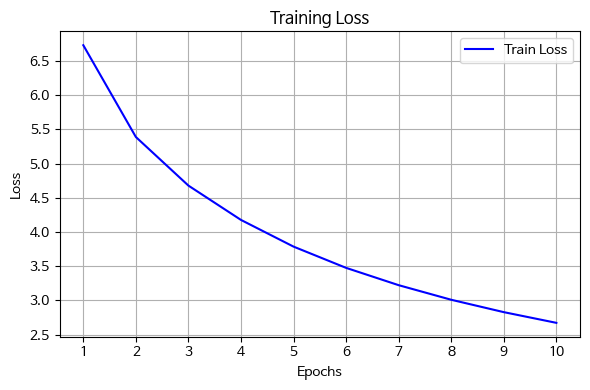

In [57]:
plot_history(history)

#### 모델 저장

In [58]:
min_loss = min(history['train_loss'])
min_loss_epoch = history['train_loss'].index(min_loss) + 1

print(min_loss)
print(min_loss_epoch)

model_name = os.path.join(os.getcwd(), f'models/train_model-epoch-{min_loss_epoch}-loss-{min_loss:.4f}-emb-{emb_dim}-h_dim-{h_dim}.pt')
print(model_name)

2.673514138777744
10
/home/minkyujeong/work/DeepDive/ch5_seq2seq/models/train_model-epoch-10-loss-2.6735-emb-256-h_dim-256.pt


In [59]:
# 모델 저장
torch.save(model.state_dict(), model_name)

# 4. 결과 확인

In [60]:
def evaluate(sentence, model, enc_tokenizer, dec_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_kor_sentence(sentence)
    src_ids = enc_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len] # 최대 길이까지만 입력 (max_len이 더 커도 에러 안 남)
    src_ids = src_ids + [0]*(max_len - len(src_ids))    
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE) # (batch: 1, src_seq_len)
        
    with torch.no_grad():
        # inference
        outs, attns = model(src_tensor, max_len=max_len) # (batch: 1, src_seq_len)
        # outs: (batch: 1, tgt_len: max_len, vocab_size)
        # attns: (batch: 1, tgt_len: max_len, src_seq_len)
    
    # vocab 중 가장 큰 단어
    # argmax(dim=2) -> (batch: 1, tgt_len: max_len)
    # squeeze(0) -> (tgt_len: max_len, ) # 예측 문장 길이만큼만 남음
    
    res = [dec_tokenizer.decode([token.item()]) for token in outs.argmax(dim=2).squeeze(0)]

    if "<end>" in res:
        res = res[:res.index("<end>")] # "<end>"값이 등장하는 index를 저장
    
    # attns: (batch: 1, tgt_len: max_len, src_seq_len) -> (tgt_len: max_len, src_seq_len)
    return res, sentence, attns.squeeze(0).cpu().numpy()
        

In [61]:
def plot_attn(attn, sentence, pred_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attn, cmap='viridis')

    fontdict = {'fontsize':11}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=45)

    ax.set_yticks(range(len(pred_sentence)))
    ax.set_yticklabels(pred_sentence, fontdict=fontdict)

    plt.show()

In [62]:
def translate(sentence, model, enc_tokenizer, dec_tokenizer, max_len=30):
    res, sentence, attn = evaluate(sentence, model, enc_tokenizer, dec_tokenizer, max_len)

    print("Input: %s"%(sentence))
    print("Predicted translation: {}".format(res))

    # Attention 크기 조정 (tgt_len, src_len)
    print(attn.shape)
    attn = attn[:len(res), :len(sentence.split())]

    plot_attn(attn, sentence.split(), res)

In [63]:
loaded_model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
checkpoint = torch.load(model_name, map_location=DEVICE)
loaded_model.load_state_dict(checkpoint)
loaded_model.eval() # 평가 모드로 변경
print("evaluation mode")

evaluation mode


In [64]:
example_sentence = [    
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

Input: 시민들은 도시 속에 산다.
Predicted translation: ['people', '']
(2, 30)


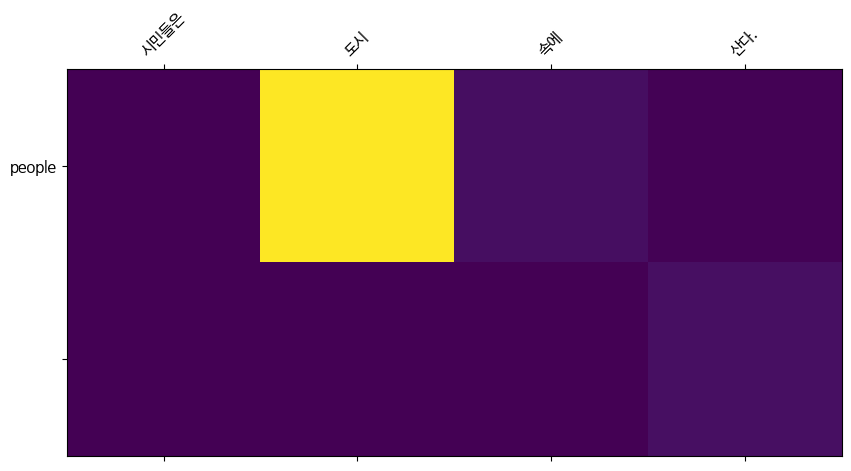

Input: 커피는 필요 없다.
Predicted translation: ['coffee', 'nutrition', '']
(3, 30)


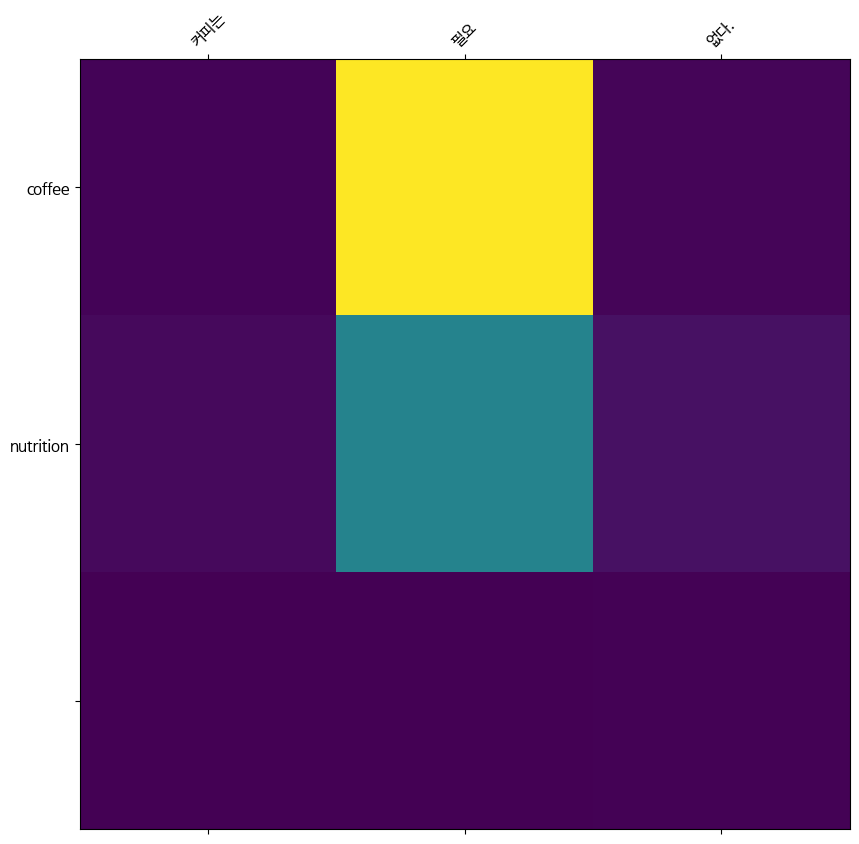

Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['deaths', 'occurred', '']
(3, 30)


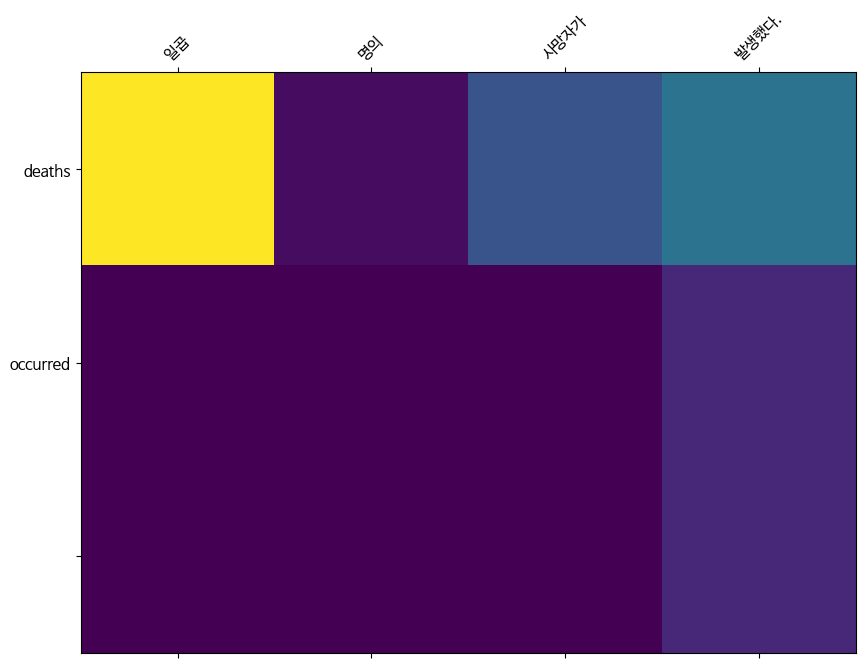

In [65]:
for sententence in example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

&rarr; 번역 성능이 좋지 않은 것을 볼 수 있음

- 학습데이터에 있는 한국어 문장으로 테스트

In [66]:
train_example_sentence = raw_df['kor'][100:200][::20]
train_example_sentence

101    1,960만갤론 이상의 중유를 운반하던 손상된 유조선이 스페인 북서부 연안 130마...
121    과거 공산주의 국가였던 7개국을 NATO에 가입하도록 요청한 이번 결정은 그 국가들...
141                  정부는 이 조치가 한국이 선진국임을 내보이는 방법이라고 말한다.
161    인터넷 감독위원회가 닷컴 이름의 위기상황을 완화하기 위하여 인터넷 상에 일단의 새로...
181    Kamen은 Segway HT라고 불리는 이 발명품이 앞으로 수 개월 동안은 제한된...
Name: kor, dtype: object

Input: 1,960만갤론 이상의 중유를 운반하던 손상된 유조선이 스페인 북서부 연안 130마일 해역에서 침몰하여, 스페인 당국이 어업이 주요 산업인 이 지역에서 해안선 보호를 위해 황급히 서두르고 있다.
Predicted translation: ['sank', 'crashed', 'cargo', 'ships', 'sank', 'miles', 'northwest', 'sank', 'sank', 'sank', 'sea', 'coast', 'spain', 'emergency', 'officials', 'said', 'spanish', 'centered', 'miles', 'spain', 'northwest', 'spain', 'sank', 'sea', 'fishing', 'miles', 'spain', 'northwest', 'cargo', 'ship']
(30, 30)


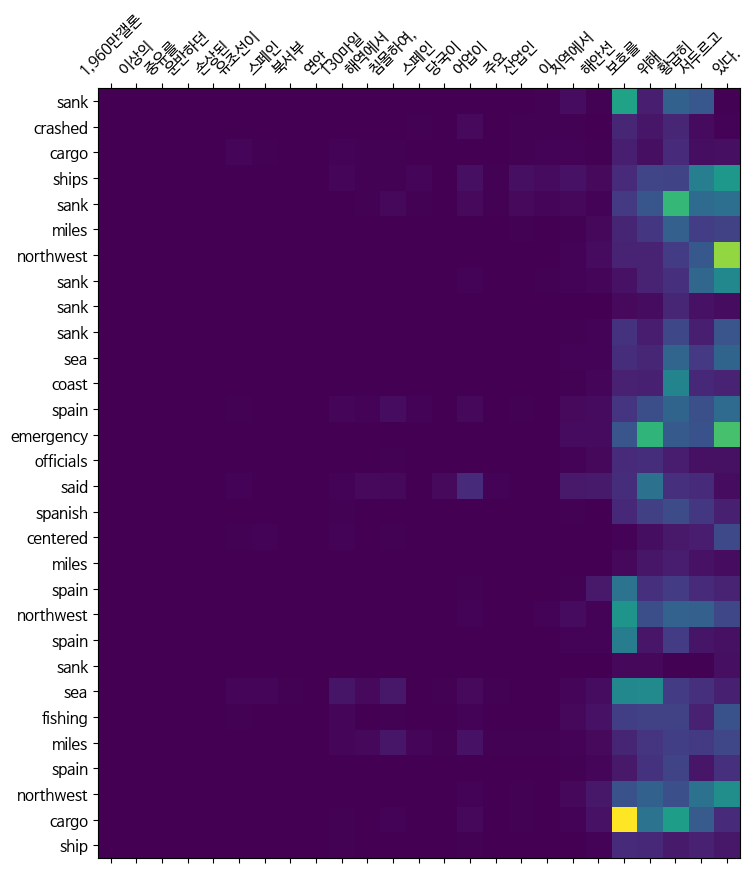

Input: 과거 공산주의 국가였던 7개국을 NATO에 가입하도록 요청한 이번 결정은 그 국가들에게는 베를린 장벽의 붕괴 만큼이나 의미심장한 것이었다.
Predicted translation: ['nato', 'countries', 'participating', 'countries', 'since', 'nato', 'leaders', 'ordered', 'national', 'countries', 'alliance', 'communist', 'nation', 'alliance', '']
(15, 30)


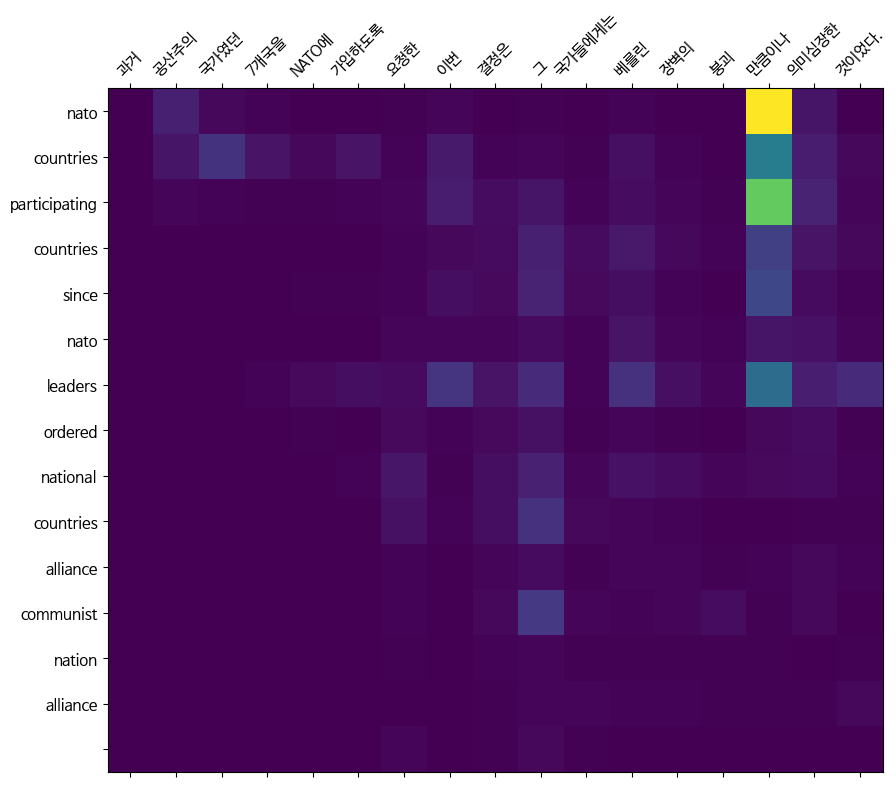

Input: 정부는 이 조치가 한국이 선진국임을 내보이는 방법이라고 말한다.
Predicted translation: ['government', 'says', 'un', 'ju', 'ven', 'i', 'ent', 'developed', 'un', 'f', 'or', 't', 'able', '']
(14, 30)


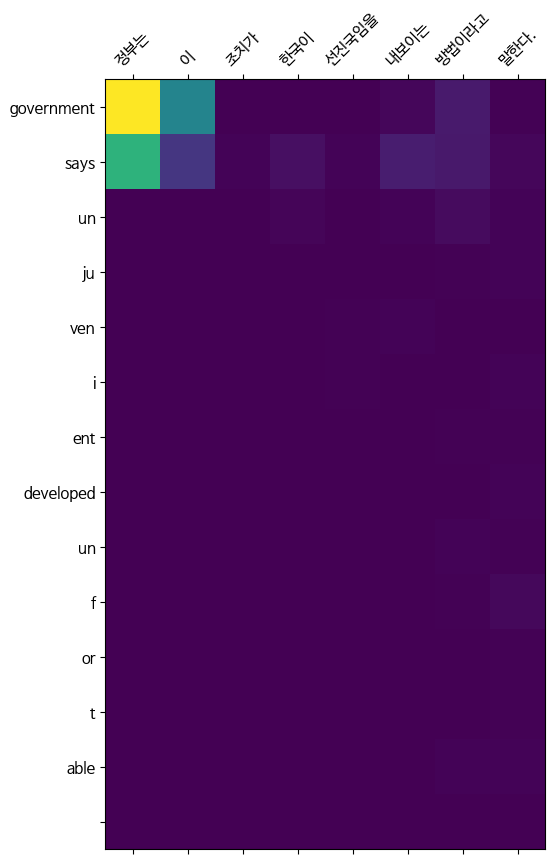

Input: 인터넷 감독위원회가 닷컴 이름의 위기상황을 완화하기 위하여 인터넷 상에 일단의 새로운 도메인 이름을 부여하기로 하고, .biz, .name, .info, .pro, .museum, .aero, 그리고 .coop를 선정했다.
Predicted translation: ['new', 'england', 'dubbed', 'deposit', 's', 'new', 'name', 'extension', 's', 'new', 'name', 'extension', 's', 'new', 'name', 'extension', 's', 'new', 'internet', 'users', '']
(21, 30)


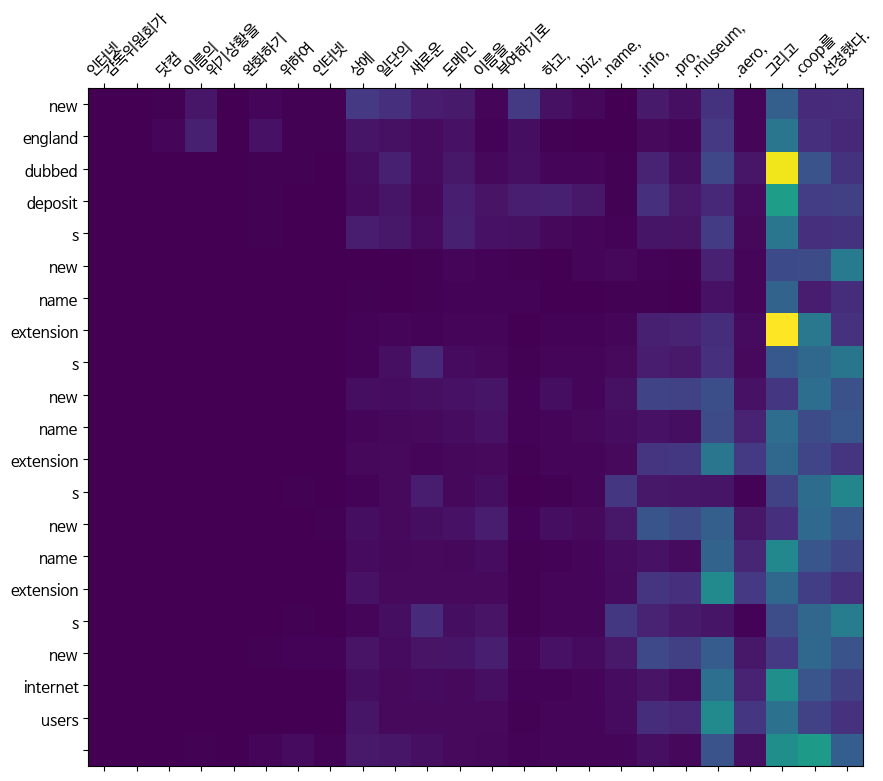

Input: Kamen은 Segway HT라고 불리는 이 발명품이 앞으로 수 개월 동안은 제한된 수량만 출시될 것이며, 내년 말이 되면 널리 사용될 것이라고 말했다.
Predicted translation: ['next', 'months', 'order', 'phoenix', 'fill', 'start', 'million', 'next', 'months', 'visitors', 'could', 'start', 'next', 'months', '']
(15, 30)


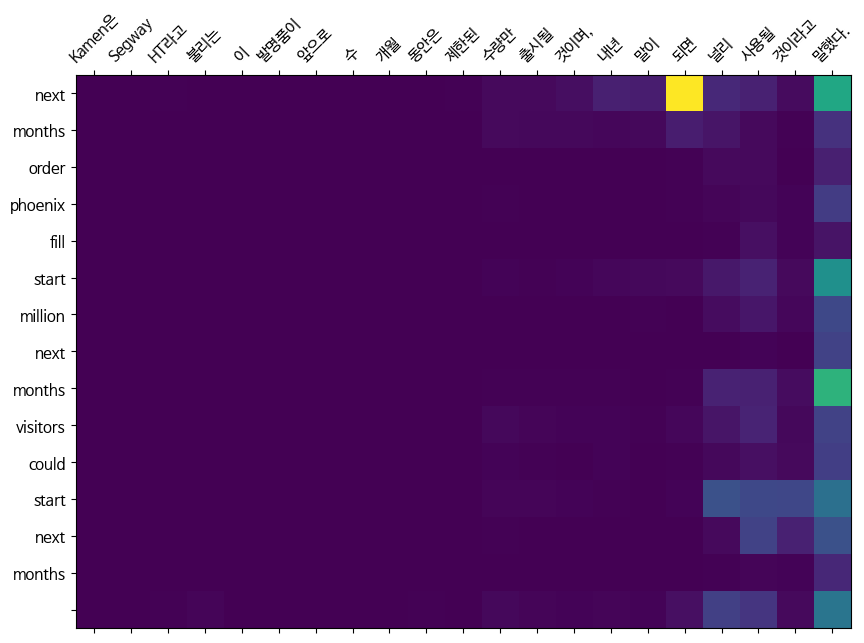

In [67]:
for sententence in train_example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

&rarr; 그래도 비슷한 의미의 단어를 출력하는 것을 볼 수 있음(doctor)  
&rarr; 불용어 제거 시 그래도 너무 잘게 쪼개지는 문제가 어느 정도 보완됨(Ex_05_seq2seq_v0.9.ipynb 참고)  
&rarr; 중간에 "new", "york", "times" 같은 단어들이 반복되는 현상으로 볼 때 overfitting이 발생한 것으로 보임

# 회고

- 코드 분석에 좀더 초점을 두고 진행을 하였다. 노드 코드와 달리 RNN 아키텍처에 데이터를 입력할 때, batch_first=True을 적용했기 때문에 연산 과정에서의 shape을 다 맞춰줘야 했다. 각 요소들을 일일이 출력해서 확인하면서 진행해서 시간이 오래 소요됐다. 그래도 어떤 과정을 거쳐서 연산이 이루어지는지 보다 구체적으로 확인할 수 있었다.
- train, validation dataset을 나누기도 어려울 정도로 데이터가 적다보니 성능이 썩 잘 나오지 않아서 augmentation을 수행하거나, 추가적인 개선안을 찾아야겠다.
- 불용어 처리를 하고 안 하고의 차이가 생각보다 큰 것을 확인할 수 있었다. (모델링보다 데이터 전처리가 더 효과가 클 수 있음을 체감함)